In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Config

In [2]:
data_dir = r"G:\Shared drives\Signatures -- large scale\baseflow\RAraki\data"
caravan_dir = r"Caravan1.4"
attributes_dir = "attributes"
timeseries_dir = r"timeseries"
data_type = "csv"
caravan_data = "hysets"

# Load data

In [3]:
attrs_cara = pd.read_csv(os.path.join(data_dir, caravan_dir, attributes_dir, caravan_data, f"attributes_caravan_hysets.{data_type}"))
attrs_cara.set_index("gauge_id", inplace=True)
attrs_cara_names = attrs_cara.columns.to_list()
attrs_HA = pd.read_csv(os.path.join(data_dir, caravan_dir, attributes_dir, caravan_data, f"attributes_hydroatlas_hysets.{data_type}"))
attrs_HA.set_index("gauge_id", inplace=True)
attrs_HA_names = attrs_HA.columns.to_list()
attrs_geo = pd.read_csv(os.path.join(data_dir, caravan_dir, attributes_dir, caravan_data, f"attributes_other_hysets.{data_type}"))
attrs_geo_names = attrs_geo.columns.to_list()
attrs_geo.set_index("gauge_id", inplace=True)
attrs_geo.head()

,gauge_name,country,gauge_lat,gauge_lon,area
gauge_id,,,,,
hysets_01010000,"St. John River at Ninemile Bridge, Maine",United States of America,46.700556,-69.715556,3467.387413
hysets_01010070,"Big Black River near Depot Mtn, Maine",United States of America,46.893889,-69.751667,475.007279
hysets_01010100,"Shields Br Big Black River nr Seven Islands, ME",United States of America,46.941625,-69.649475,404.295872
hysets_01010500,"St. John River at Dickey, Maine",United States of America,47.113056,-69.088056,6942.099132
hysets_01012515,CLAYTON STREAM AT OUTLET CLAYTON LAKE ME SITE 6,United States of America,46.730631,-68.771453,33.899206


In [4]:
us_gauges = attrs_geo[attrs_geo["country"]=="United States of America"].copy()
print(us_gauges.describe())
us_gauges.head()

          gauge_lat     gauge_lon           area
count  10683.000000  10683.000000   10683.000000
mean      39.370051    -96.587536    1459.838883
std        4.773722     16.214746    7174.943371
min       26.932558   -124.669121       0.724949
25%       35.953292   -111.193040      46.090467
50%       39.572661    -92.881005     180.560047
75%       42.700945    -82.799164     667.755581
max       48.998514    -67.266944  178592.039189


,gauge_name,country,gauge_lat,gauge_lon,area
gauge_id,,,,,
hysets_01010000,"St. John River at Ninemile Bridge, Maine",United States of America,46.700556,-69.715556,3467.387413
hysets_01010070,"Big Black River near Depot Mtn, Maine",United States of America,46.893889,-69.751667,475.007279
hysets_01010100,"Shields Br Big Black River nr Seven Islands, ME",United States of America,46.941625,-69.649475,404.295872
hysets_01010500,"St. John River at Dickey, Maine",United States of America,47.113056,-69.088056,6942.099132
hysets_01012515,CLAYTON STREAM AT OUTLET CLAYTON LAKE ME SITE 6,United States of America,46.730631,-68.771453,33.899206


In [5]:
attrs_geo['HUC'] = attrs_geo.index.str.split('_').str[1].str[:2]
attrs_geo_agg = attrs_geo.groupby('HUC')['area'].agg(['min', 'max', 'median', 'mean', 'var'])
attrs_geo_agg.to_csv(r"G:\Shared drives\Signatures -- large scale\baseflow\RAraki\out\caravan_datacheck\hysets_stat_area_by_HUC.csv")

# Pick a gauge and investigate

In [6]:
us_gauge = us_gauges.iloc[0]

       snow_depth_water_equivalent_mean  surface_net_solar_radiation_mean  \
count                      26662.000000                      26662.000000   
mean                          59.378972                        118.904814   
std                           86.504529                         80.089028   
min                            0.000000                          2.300000   
25%                            0.000000                         48.270000   
50%                            1.960000                        101.705000   
75%                          106.555000                        180.717500   
max                          443.200000                        318.810000   

       surface_net_thermal_radiation_mean  surface_pressure_mean  \
count                        26662.000000           26662.000000   
mean                           -52.027711              97.511951   
std                             25.491579               0.816836   
min                           -112

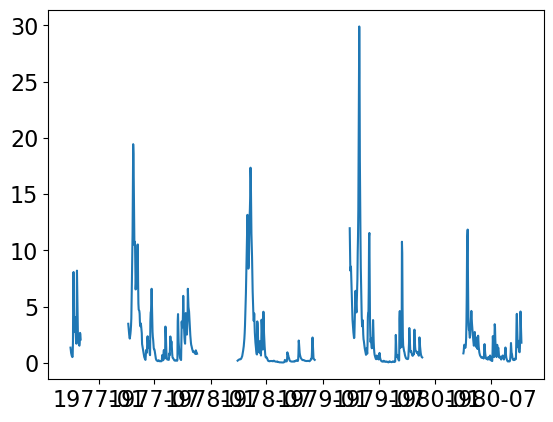

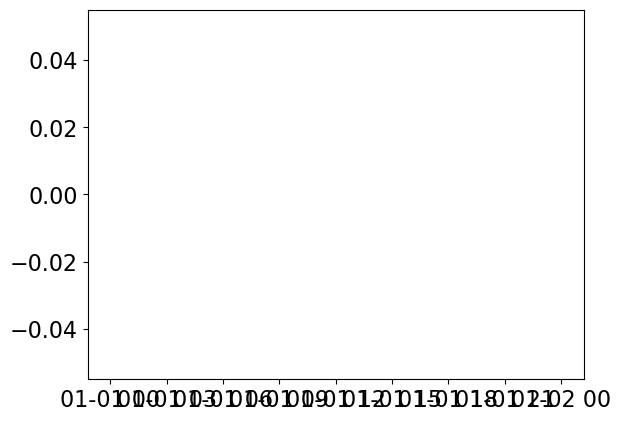

In [7]:
check_gauge_id = "hysets_01010100"
data = pd.read_csv(os.path.join(data_dir, caravan_dir, timeseries_dir, data_type, caravan_data, f"{check_gauge_id}.{data_type}"))
print(data.describe())

start_date = data.date.iloc[0]
end_date = data.date.iloc[-1]
nan_count = data.streamflow.isna().sum()
nan_fraction = nan_count/len(data.streamflow)

plt.plot(pd.to_datetime(data.date), data.streamflow)
plt.show()
plt.plot(pd.to_datetime(data.date)[0:700], data.streamflow[0:700])
plt.show()

# Visualize quality assessment output of Hysets

In [8]:
filename = r"G:\Shared drives\Signatures -- large scale\baseflow\RAraki\out\caravan_datacheck\hysets_summary.csv"
hysets_qa = pd.read_csv(filename)
hysets_qa.set_index("gauge_id",inplace=True)

# Calculate some stats
hysets_qa["start_date"] = pd.to_datetime(hysets_qa["start_date"])
hysets_qa["end_date"] = pd.to_datetime(hysets_qa["end_date"])

hysets_qa['start_year'] = hysets_qa['start_date'].dt.year
hysets_qa['end_year'] = hysets_qa['end_date'].dt.year

hysets_qa['duration_yr'] = (hysets_qa['end_date'] - hysets_qa['start_date']).dt.days / 365



hysets_qa.head()

,start_date,end_date,nan_count,nan_fraction,subset_nan_fraction,start_year,end_year,duration_yr
gauge_id,,,,,,,,
hysets_01010000,1951-01-01,2018-12-31,1825,0.068449,0.000000,1951,2018,68.043836
hysets_01010070,1983-10-01,2018-12-31,13786,0.517065,0.000000,1983,2018,35.273973
hysets_01010100,1976-10-01,1980-10-08,25724,0.964819,0.361963,1976,1980,4.021918
hysets_01010500,1951-01-01,2018-12-31,1825,0.068449,0.000000,1951,2018,68.043836
hysets_01012515,1982-07-15,1984-06-13,25962,0.973745,0.000000,1982,1984,1.915068


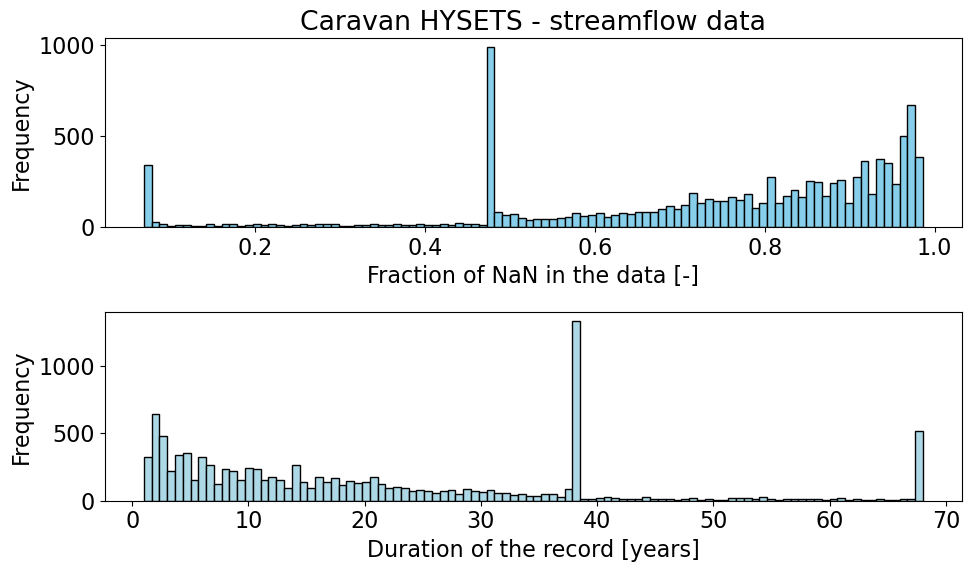

In [9]:
# Creating a 2x1 subplot layout
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# Plotting the start year histogram
ax[0].hist(hysets_qa['nan_fraction'], bins=100, color='skyblue', edgecolor='black')
ax[0].set_title('Caravan HYSETS - streamflow data')
ax[0].set_xlabel('Fraction of NaN in the data [-]')
ax[0].set_ylabel('Frequency')

# Plotting the end year histogram
ax[1].hist(hysets_qa['duration_yr'], bins=100, color='lightblue', edgecolor='black')
ax[1].set_xlabel('Duration of the record [years]')
ax[1].set_ylabel('Frequency')

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


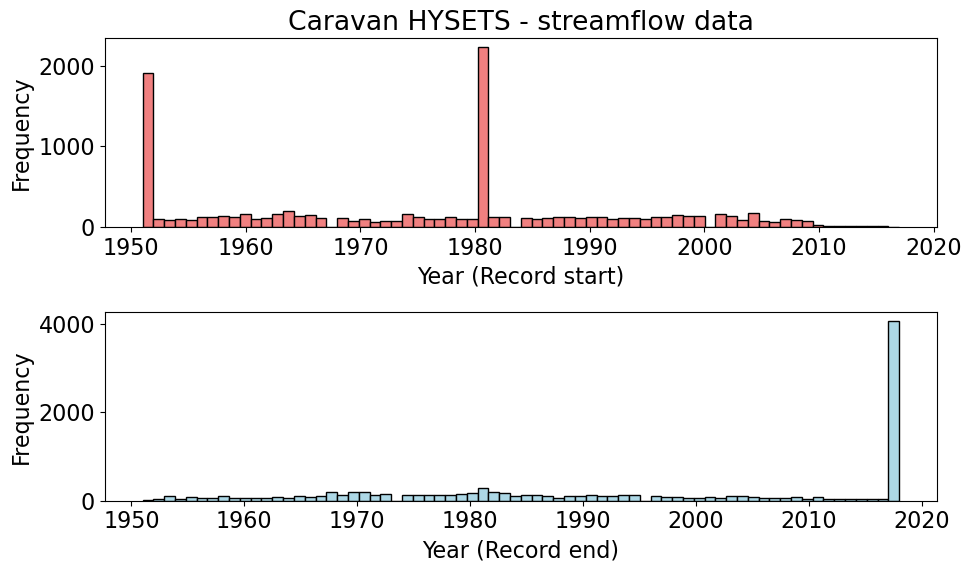

In [10]:


# Creating a 2x1 subplot layout
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# Plotting the start year histogram
ax[0].hist(hysets_qa['start_year'], bins=70, color='lightcoral', edgecolor='black')
ax[0].set_title('Caravan HYSETS - streamflow data')
ax[0].set_xlabel('Year (Record start)')
ax[0].set_ylabel('Frequency')

# Plotting the end year histogram
ax[1].hist(hysets_qa['end_year'], bins=70, color='lightblue', edgecolor='black')
ax[1].set_xlabel('Year (Record end)')
ax[1].set_ylabel('Frequency')

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()



In [11]:
hysets_qa.head()
hysets_qa = hysets_qa.join(attrs_geo)

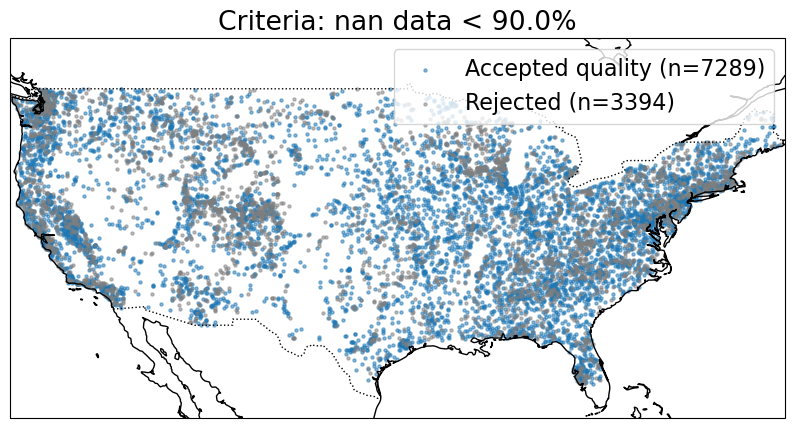

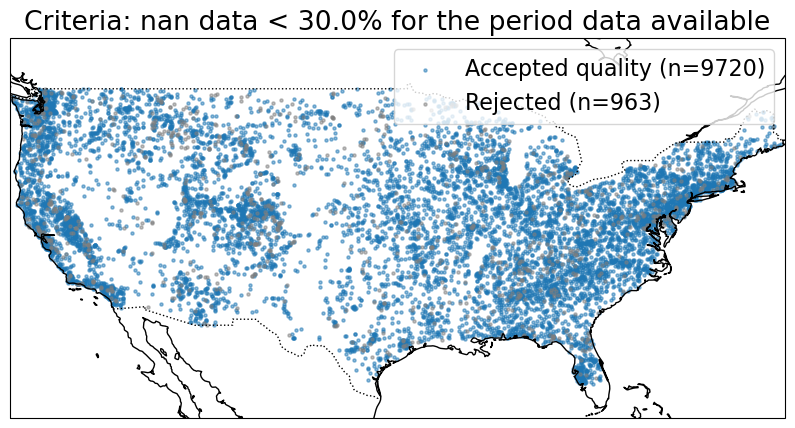

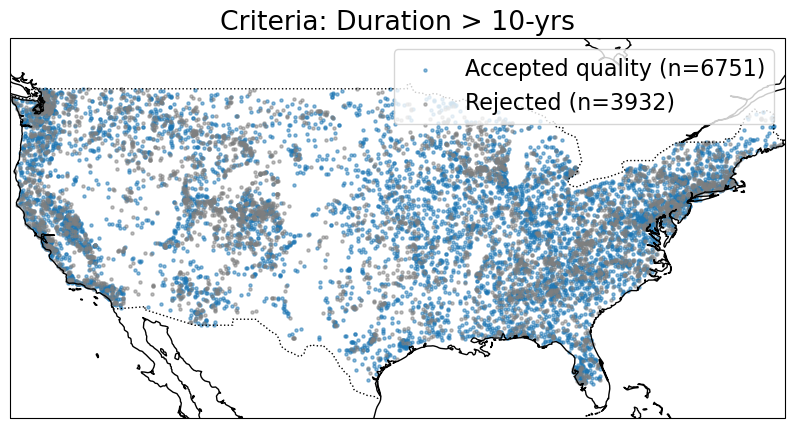

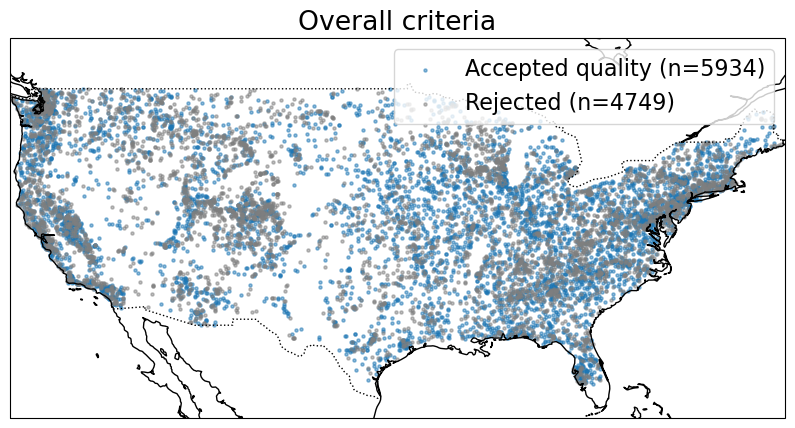

In [12]:
# Apply the filtering criteria

def plot_filtered_locations(df, criteria, label):

    good_data = df[df[criteria]]
    bad_data = df[~df[criteria]]

    # Set up the map
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # Add map features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # Set extent to CONUS
    ax.set_extent([-124.85, -66.95, 24.396308, 49.384358])




    # Plotting the filtered data
    ax.scatter(good_data['gauge_lon'], good_data['gauge_lat'], color='tab:blue', s=5, label=f"Accepted quality (n={len(good_data)})", alpha=0.5)

    # Plotting the filtered data in red
    ax.scatter(bad_data['gauge_lon'], bad_data['gauge_lat'], color='tab:grey', s=5, label=f'Rejected (n={len(bad_data)})', alpha=0.5)

    # Add a legend
    ax.legend()
    ax.set_title(label)

    # Show the plot
    plt.show()


nan_fraction_thresh = 0.9
hysets_qa["qf_nan_fraction"] = hysets_qa["nan_fraction"] < nan_fraction_thresh
plot_filtered_locations(hysets_qa, "qf_nan_fraction", f"Criteria: nan data < {nan_fraction_thresh*100}%")

subset_nan_fraction_thresh = 0.3
hysets_qa["qf_subset_nan_fraction"] = hysets_qa["subset_nan_fraction"] < subset_nan_fraction_thresh
plot_filtered_locations(hysets_qa, "qf_subset_nan_fraction", f"Criteria: nan data < {subset_nan_fraction_thresh*100}% for the period data available")

duration_thresh = 10
hysets_qa["qf_duration"] = hysets_qa["duration_yr"] > duration_thresh
plot_filtered_locations(hysets_qa, "qf_duration", f"Criteria: Duration > {duration_thresh}-yrs")


hysets_qa["qf_overall"] = hysets_qa["qf_subset_nan_fraction"] & hysets_qa["qf_duration"] 
plot_filtered_locations(hysets_qa, "qf_overall", f"Overall criteria")

In [13]:
hysets_qa = hysets_qa.join(attrs_cara)
hysets_qa.columns

Index(['start_date', 'end_date', 'nan_count', 'nan_fraction',
       'subset_nan_fraction', 'start_year', 'end_year', 'duration_yr',
       'gauge_name', 'country', 'gauge_lat', 'gauge_lon', 'area', 'HUC',
       'qf_nan_fraction', 'qf_subset_nan_fraction', 'qf_duration',
       'qf_overall', 'p_mean', 'pet_mean', 'aridity', 'frac_snow',
       'moisture_index', 'seasonality', 'high_prec_freq', 'high_prec_dur',
       'low_prec_freq', 'low_prec_dur'],
      dtype='object')

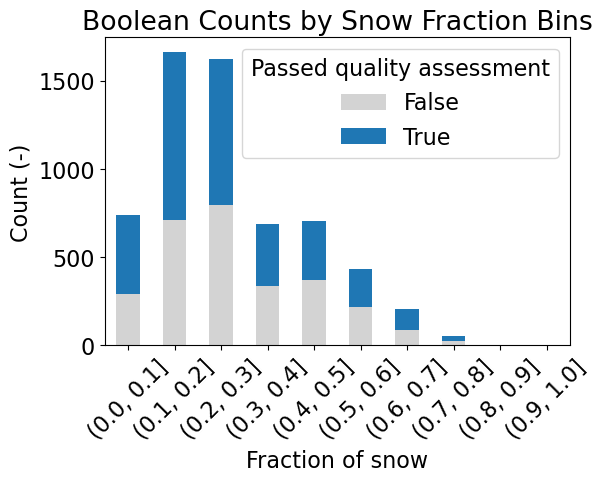

In [14]:
hysets_qa['frac_snow_bin'] = pd.cut(hysets_qa['frac_snow'], bins=np.linspace(0, 1, num=11))
# Grouping by frac_snow_bin and qf_overall, then counting occurrences
count_data = hysets_qa.groupby(['frac_snow_bin', 'qf_overall']).size().unstack(fill_value=0).copy()
count_data.plot(kind='bar', stacked=True, color=['lightgrey','tab:blue'], figsize=(6, 4))
plt.title('Boolean Counts by Snow Fraction Bins')
plt.xlabel('Fraction of snow')
plt.ylabel('Count (-)')
plt.xticks(rotation=45)
plt.legend(title='Passed quality assessment')
plt.show()


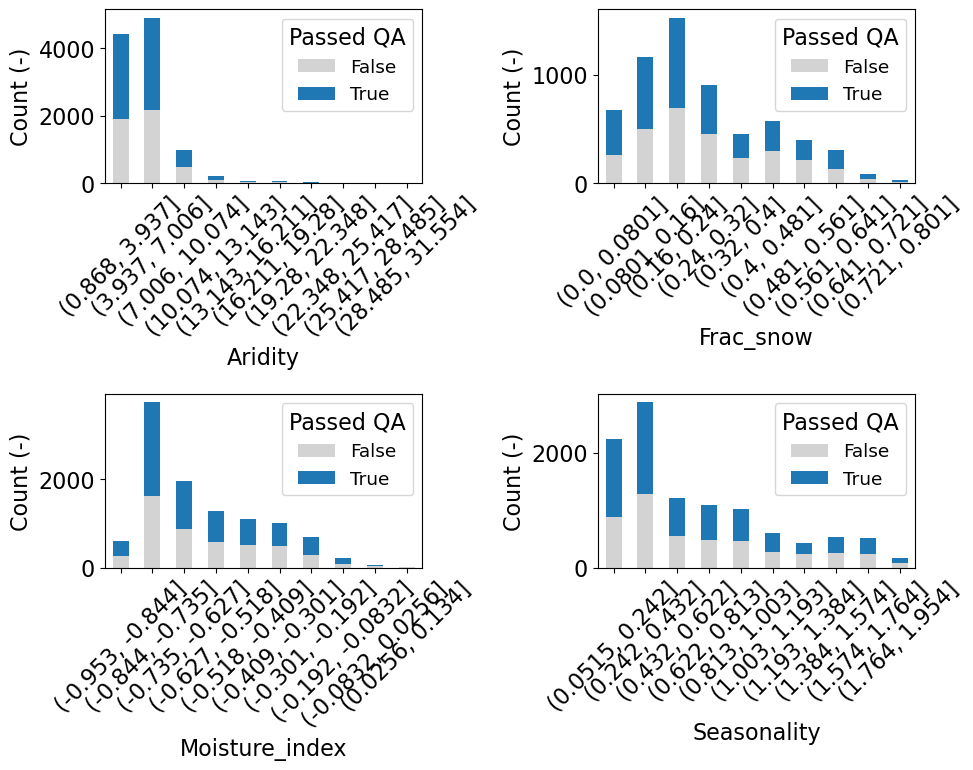

In [15]:

def plot_boolean_counts(df, variable, bins=11, plot_color=['lightgrey', 'tab:blue']):
    """
    Plots boolean counts grouped by a specified environmental variable.

    Parameters:
    df (DataFrame): The input DataFrame.
    variable (str): The environmental variable to analyze.
    bins (int): Number of bins to use for the numerical variable.
    plot_color (list): List of colors for the plot.
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # Set up a 2x2 subplot grid
    axes = axes.flatten()  # Flatten the 2D array of axes to make iteration easier

    for i, variable in enumerate(variables):
        # Binning the specified variable
        df[f'{variable}_bin'] = pd.cut(df[variable], bins=np.linspace(df[variable].min(), df[variable].max(), num=bins))

        # Grouping by the binned variable and qf_overall, then counting occurrences
        count_data = df.groupby([f'{variable}_bin', 'qf_overall']).size().unstack(fill_value=0)

        # Plotting on the appropriate subplot
        count_data.plot(kind='bar', stacked=True, color=plot_color, ax=axes[i])
        axes[i].set_xlabel(variable.capitalize())
        axes[i].set_ylabel('Count (-)')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(title='Passed QA', fontsize='small')

    plt.tight_layout()
    plt.show()

variables = ['aridity', 'frac_snow', 'moisture_index', 'seasonality']
plot_boolean_counts(hysets_qa, variables)

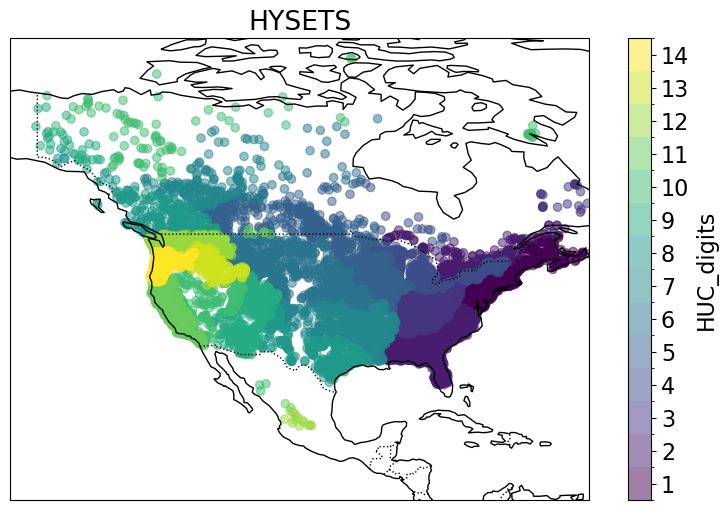

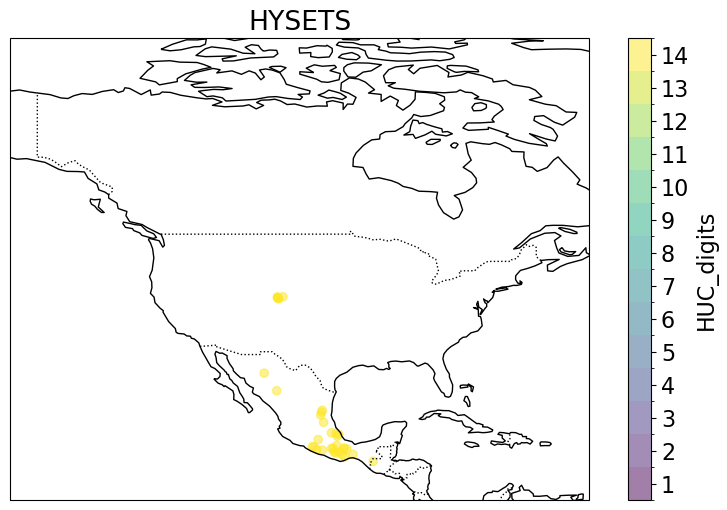

In [16]:
def plot_map(df, varname):

    # Set up the map
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # Add map features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # Set extent to CONUS
    # ax.set_extent([-124.85, -66.95, 24.396308, 49.384358])
    ax.set_extent([-145, -60, 10, 74])  # Adjusted to include Alaska and Puerto Rico
    # ax.set_extent([-130, -60, 30, 75])
    # Plotting the filtered data

    # Define the boundaries for each color and normalize
    n_colors = 14  # Number of discrete colors
    cmap = plt.get_cmap('viridis', n_colors)  # Get a colormap with n discrete colors
    boundaries = np.arange(0.5, n_colors+1.5, 1)  # Creates boundaries for 1 to 14
    norm = BoundaryNorm(boundaries, n_colors)

    scatter=ax.scatter(df['gauge_lon'], df['gauge_lat'], c=df[varname], alpha=0.5, cmap=cmap, norm=norm)
    cb = plt.colorbar(scatter, ax=ax, boundaries=boundaries, ticks=np.arange(1, 15), spacing='proportional')
    # scatter=ax.scatter(df['gauge_lon'], df['gauge_lat'], c=df[varname], alpha=0.5)
    # cb = plt.colorbar(scatter, ax=ax)
    # Create a colorbar
    
    cb.set_label(varname)
    ax.set_title("HYSETS")

    # Show the plot
    plt.show()

from matplotlib.colors import ListedColormap, BoundaryNorm
attrs_geo['HUC_digits'] = attrs_geo['HUC'].astype(int)
plot_map(attrs_geo[attrs_geo["HUC_digits"]<15].copy(), "HUC_digits")
plot_map(attrs_geo[attrs_geo["HUC_digits"]>14].copy(), "HUC_digits")